### Loading Data and Libraries

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

DATA_PATH = Path("../data/processed/pricing_analyst_cleaned.csv")
FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR = Path("../outputs/tables")

df_analysis = pd.read_csv(DATA_PATH)

date_columns = ["offerdate", "purchase_date"]
for col in date_columns:
    df_analysis[col] = pd.to_datetime(df_analysis[col], errors="coerce")

print(df_analysis.shape)
df_analysis.info()
display(df_analysis.head())

(8865, 24)
<class 'pandas.DataFrame'>
RangeIndex: 8865 entries, 0 to 8864
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   offerdate                      8865 non-null   datetime64[us]
 1   sold_premium                   1991 non-null   float64       
 2   offered_premium                8865 non-null   float64       
 3   purchase_price                 8864 non-null   float64       
 4   purchase_date                  8865 non-null   datetime64[us]
 5   item_age                       8862 non-null   float64       
 6   pricing_point                  8865 non-null   str           
 7   predictedconversionrate        8865 non-null   float64       
 8   plan_flag                      8865 non-null   int64         
 9   plan_count                     8824 non-null   float64       
 10  plansactive_lastyear_count     8824 non-null   float64       
 11  planscancelled_la

,offerdate,sold_premium,offered_premium,purchase_price,purchase_date,item_age,pricing_point,predictedconversionrate,plan_flag,plan_count,...,price_diff,ismodel,sale_flag,base_rate,manufacturerbrandname_enc,itemcategoryname_enc,itemsupercategorycode_enc,invalid_price_flag,price_diff_check,price_diff_matches
0,2023-03-17,NaN,32.64,89.99,2023-03-16,1.0,@22%,0.15,0,0.0,...,-0.058824,yes,0,34.68,56,35,14,False,-1.981176,False
1,2023-03-01,69.72,69.72,329.00,2022-12-24,67.0,@22%,0.81,1,5.0,...,-0.023529,yes,1,71.40,123,34,3,False,-1.656471,False
2,2023-04-12,NaN,48.24,249.00,2023-04-05,7.0,@23%,0.08,0,0.0,...,0.210843,yes,0,39.84,7,16,12,False,8.189157,False
3,2023-03-09,NaN,91.92,746.42,2021-03-09,730.0,@23%,0.32,0,0.0,...,0.298305,yes,0,70.80,107,36,4,False,20.821695,False
4,2023-03-18,NaN,89.64,493.98,2023-03-18,0.0,@22%,0.25,1,1.0,...,0.299130,yes,0,69.00,57,36,4,False,20.340870,False


## Conversion and Claims Relationship

In [5]:
df_analysis["has_claim"] = df_analysis["claims_count"].fillna(0) > 0

claims_contingency = pd.crosstab(df_analysis["has_claim"], df_analysis["sale_flag"])
display(claims_contingency)

chi2_claims, p_value_claims, dof_claims, expected_claims = chi2_contingency(claims_contingency)

print(f"Chi-square statistic: {chi2_claims:.2f}")
print(f"p-value: {p_value_claims:.10f}")

sale_flag,0,1
has_claim,,
False,6465,1612
True,409,379


Chi-square statistic: 324.81
p-value: 0.0000000000


In [6]:
conversion_by_claims_strategy = (
    df_analysis
    .groupby(["pricing_point", "has_claim"], observed=True)["sale_flag"]
    .mean()
    .unstack()
)

conversion_by_claims_strategy.columns = ["no_claim", "has_claim"]
display(conversion_by_claims_strategy)

,no_claim,has_claim
pricing_point,,
@22%,0.194802,0.484058
@23%,0.203264,0.470060
ASIS FEE,0.203777,0.504587


In [7]:
claim_severity_by_conversion = (
    df_analysis[df_analysis["has_claim"]]
    .groupby("sale_flag")["claim_amount"]
    .agg(["mean", "median", "count"])
)

display(claim_severity_by_conversion)

from scipy.stats import ttest_ind

converted_claims = df_analysis.loc[(df_analysis["has_claim"]) & (df_analysis["sale_flag"] == 1), "claim_amount"]
not_converted_claims = df_analysis.loc[(df_analysis["has_claim"]) & (df_analysis["sale_flag"] == 0), "claim_amount"]

t_stat_claims, p_value_claims_amount = ttest_ind(converted_claims, not_converted_claims, equal_var=False)

print(f"t = {t_stat_claims:.2f}, p = {p_value_claims_amount:.6f}")

,mean,median,count
sale_flag,,,
0,292.639560,150.00,409
1,279.516834,170.06,379


t = -0.36, p = 0.720148


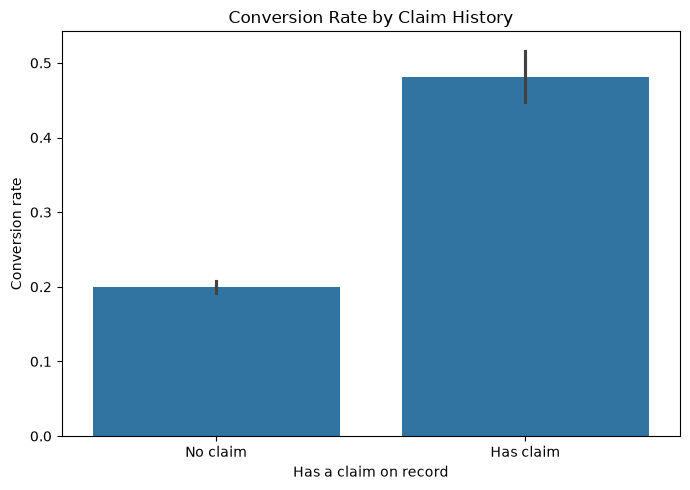

In [8]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df_analysis,
    x="has_claim",
    y="sale_flag",
    errorbar=("ci", 95)
)
plt.title("Conversion Rate by Claim History")
plt.xlabel("Has a claim on record")
plt.ylabel("Conversion rate")
plt.xticks([0, 1], ["No claim", "Has claim"])
plt.tight_layout()
plt.savefig("../outputs/figures/conversion_by_claims.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
claim_plan_crosstab = pd.crosstab(df_analysis["has_claim"], df_analysis["plan_flag"], normalize="index")
display(claim_plan_crosstab)

plan_flag,0,1
has_claim,,
False,0.866287,0.133713
True,0.152284,0.847716


In [10]:
plan_claim_crosstab = pd.crosstab(df_analysis["plan_flag"], df_analysis["has_claim"], normalize="index")
display(plan_claim_crosstab)

conversion_by_plan_and_claim = (
    df_analysis
    .groupby(["plan_flag", "has_claim"])["sale_flag"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "conversion_rate", "size": "n"})
)

display(conversion_by_plan_and_claim)

has_claim,False,True
plan_flag,,
0,0.983139,0.016861
1,0.617849,0.382151


conversion_rate     n
plan_flag has_claim                       
0         False             0.162641  6997
          True              0.333333   120
1         False             0.438889  1080
          True              0.507485   668